<div class="alert alert-block alert-danger">
    <b> Unraveling the cytoskeletal architecture of cancer cells: a novel computational approach to predict cell fate - CODE</b> 
    
 **2 - NUCLEI PREPROCESSING**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.preprocessingNUCL import *

print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["NUCL"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [NUCL] added.


In [4]:
data['NUCL']

,Path,Name,Label,Label 2,Resolution,Image,Image Size
HPA,C:\Users\diogo\OneDrive - Universidade de Lisb...,Cells_HPA_Cells_abc.tif,Cells,abc.tif,"(1, 0.08, 0.08)","[[0, 0, 0, 0, 0, 0, 257, 0, 0, 0, 257, 0, 0, 0...","(2048, 2048)"


<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Select an image.

**2.** Perform nuclei segmentation to the selected image. Choose the algorithm to use and tune the necessary parameters. Once satisfied with the results, save the masks on the predefined folder.

**3.** Perform nuclei preprocessing on the selected image, using the segmentation mask saved previously. Every time this function is applied, ```data['NUCL_PRE']``` will be filled with the nuclei (centroids and contours) obtained from the current image.

**4.** If you have a dataset of images, repeat this process with another image. In the end, ```data['NUCL_PRE']``` must be filled with nuclei (centroids and contours) identified from multiple images. 

**5.** Save the final dataframe.

<div class="alert alert-block alert-info">
    
 **SELECT IMAGE**
    
</div>

In [3]:
# IMAGE SELECTION
def dropdown_image_eventhandler(change):
    global idx
    idx = dropdown_image.value
    lab = data['NUCL']['Label'][dropdown_image.value]
    print('Image ' + str(idx) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Image:' , options = ['...'] + list(data['NUCL'].index))
dropdown_image.observe(dropdown_image_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Image:', options=('...', 'HPA'), value='...')

Image HPA (Cells) selected.


<div class="alert alert-block alert-info">
    
 **NUCLEI SEGMENTATION**
    
</div>

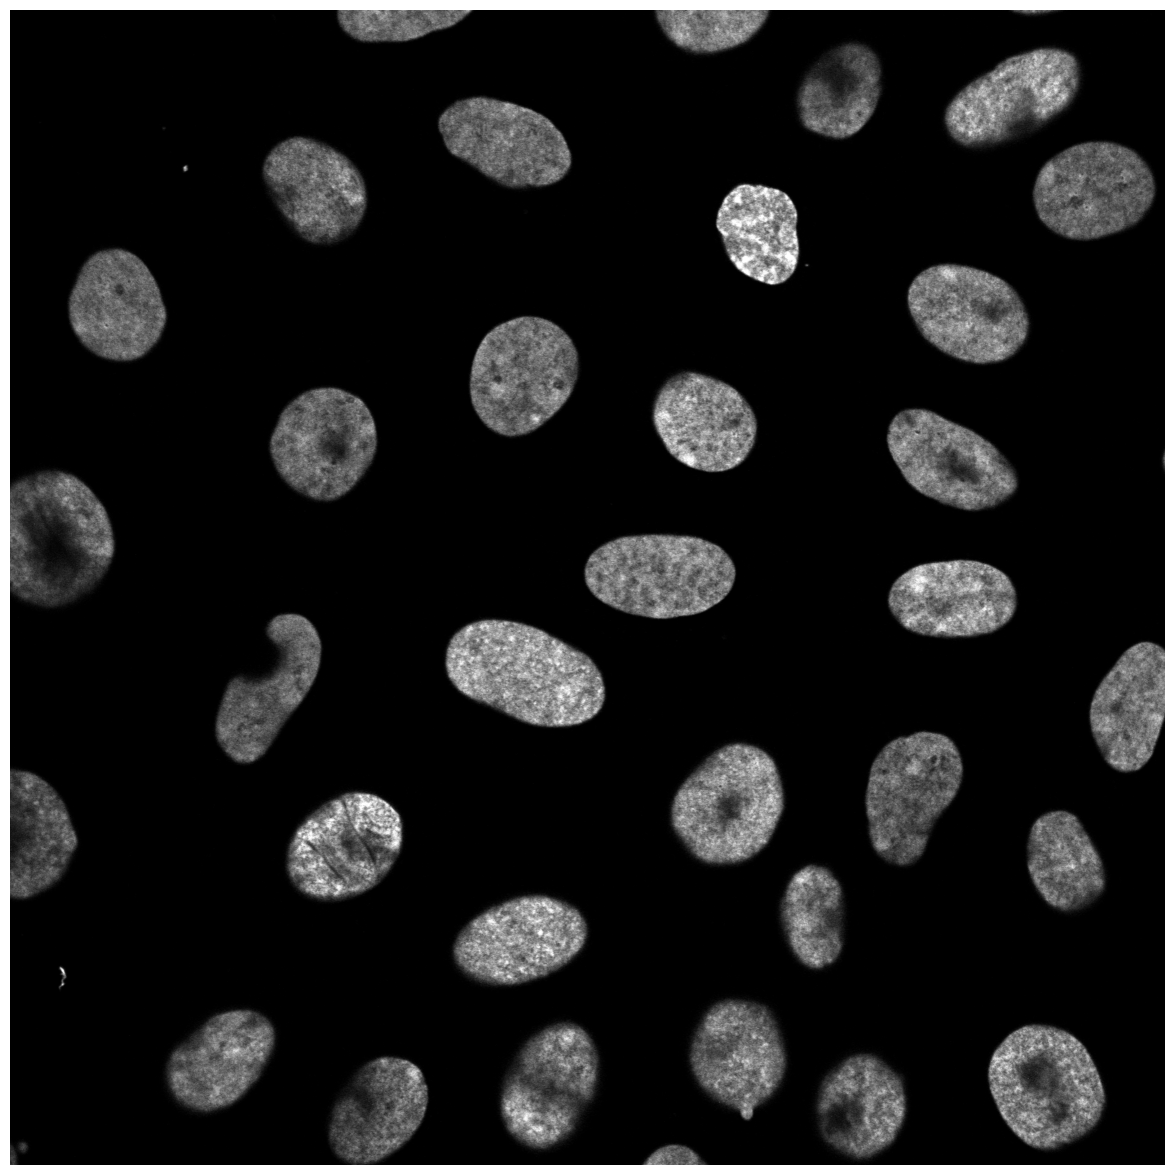

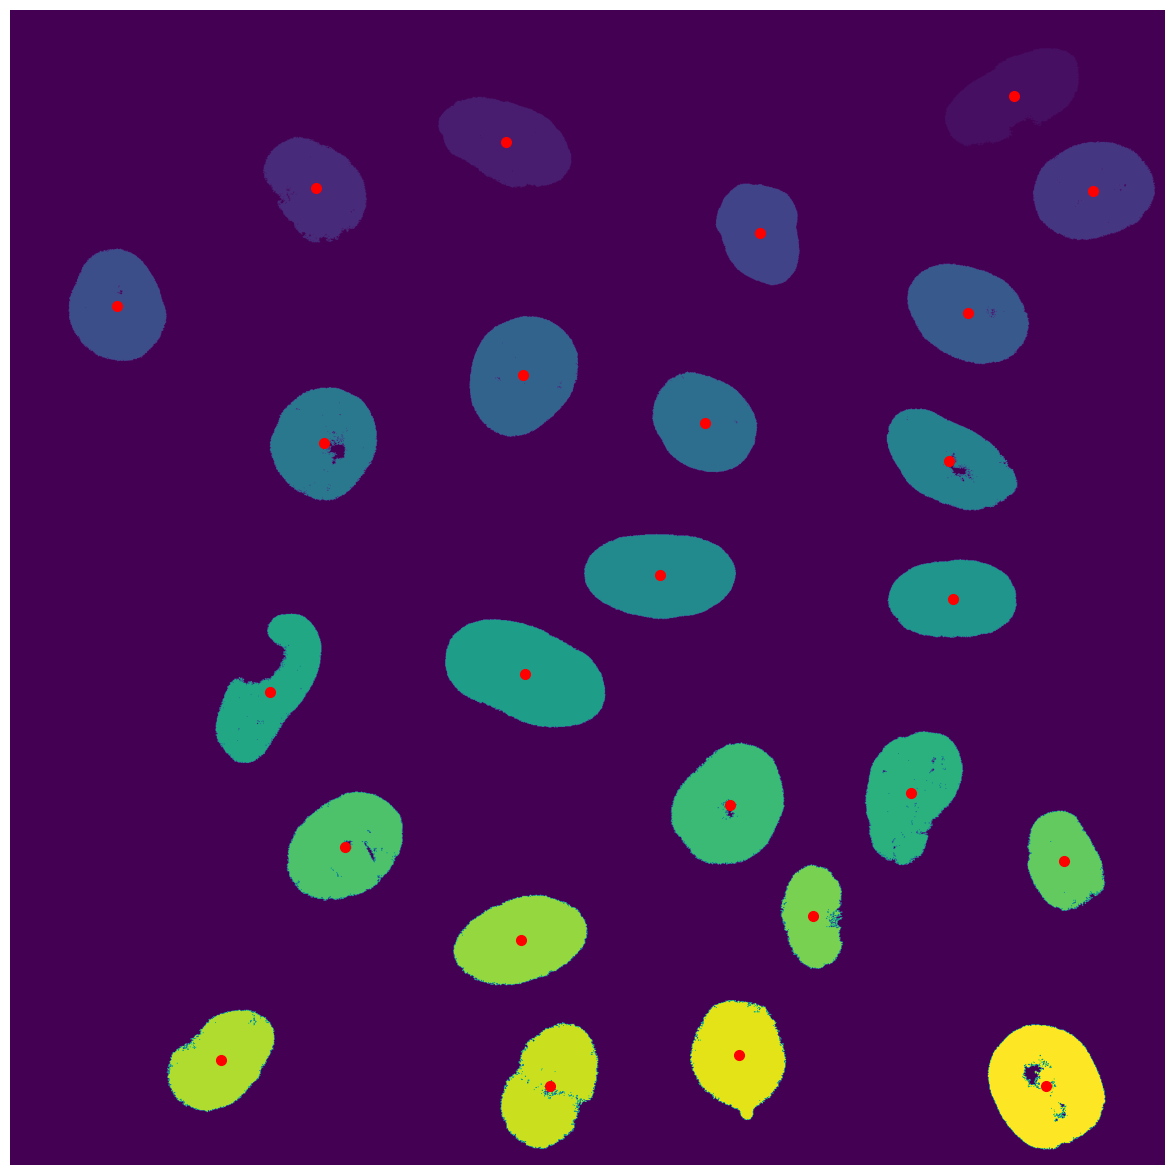

0.7 , None , 200 , 0.3 , 300


In [4]:
nuclei_segmentation(rowNUCL    = data["NUCL"].loc[idx],
                    algorithm  = "contour",
                    parameters = {'otsu_frac': 0.7,
                             'wtshed_mindist': 200,
                                 'wtshed_thr': 0.3,
                                   'min_size': 300,
                                   'dilation': None},
                    plot       = True,
                    save       = os.path.join(folder,"NUCL_PRE","Masks"))

<div class="alert alert-block alert-info">
    
 **NUCLEI PREPROCESSING**
    
</div>

Initial number of nuclei: 25
Progress: 3.8461538461538463%
Progress: 7.6923076923076925%
Progress: 11.538461538461538%
Progress: 15.384615384615385%
Progress: 19.23076923076923%
Progress: 23.076923076923077%
Progress: 26.923076923076923%
Progress: 30.76923076923077%
Progress: 34.61538461538461%
Progress: 38.46153846153846%
Progress: 42.30769230769231%
Progress: 46.15384615384615%
Progress: 50.0%
Progress: 53.84615384615385%
Progress: 57.69230769230769%
Progress: 61.53846153846154%
Progress: 65.38461538461539%
Progress: 69.23076923076923%
Progress: 73.07692307692308%
Progress: 76.92307692307692%
Progress: 80.76923076923077%
Progress: 84.61538461538461%
Progress: 88.46153846153847%
Progress: 92.3076923076923%
Progress: 96.15384615384616%


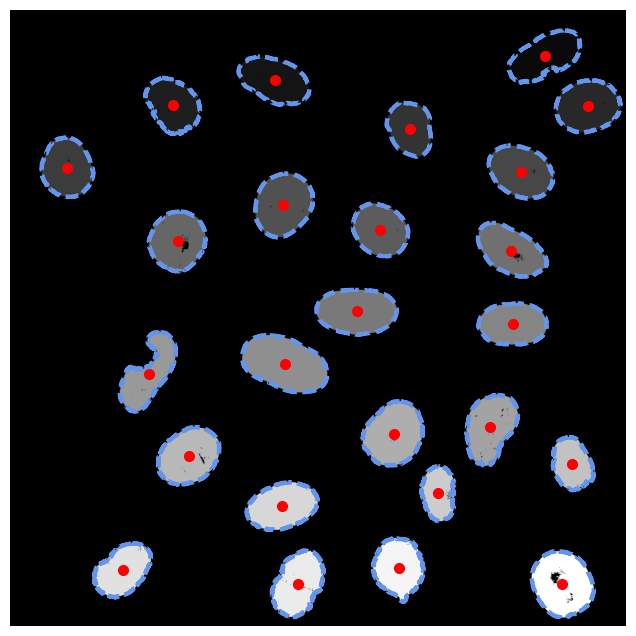

In [5]:
data['NUCL_PRE'] = nuclei_preprocessing(rowNUCL   = data['NUCL'].loc[idx],
                                        dir_masks = os.path.join(folder,"NUCL_PRE","Masks"),
                                        options   = {'sizefilt':150},
                                        plot      = True,
                                        save      = os.path.join(folder,"NUCL_PRE"))

In [6]:
data['NUCL_PRE']

,Path,Img Index,Label,Label 2,Label ID,Image Size,Nucleus Mask,Centroid,Contour
0,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,1,"(2048, 2048)","[[67, 67, 68, 68, 68, 68, 68, 68, 68, 68, 68, ...","(152.409, 1778.906)","[[[1839, 67]], [[1838, 68]], [[1837, 68]], [[1..."
1,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,2,"(2048, 2048)","[[154, 154, 154, 154, 154, 154, 154, 154, 154,...","(233.328, 879.191)","[[[821, 154]], [[820, 155]], [[819, 156]], [[8..."
2,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,3,"(2048, 2048)","[[225, 225, 225, 225, 225, 225, 225, 225, 226,...","(315.514, 542.272)","[[[504, 225]], [[503, 226]], [[502, 226]], [[5..."
3,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,4,"(2048, 2048)","[[233, 233, 233, 234, 234, 234, 234, 234, 234,...","(319.796, 1920.438)","[[[1928, 233]], [[1927, 234]], [[1926, 234]], ..."
4,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,5,"(2048, 2048)","[[308, 308, 308, 308, 308, 308, 308, 308, 308,...","(394.054, 1329.819)","[[[1295, 308]], [[1295, 309]], [[1294, 310]], ..."
5,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,6,"(2048, 2048)","[[423, 423, 423, 424, 424, 424, 424, 424, 424,...","(525.09, 189.429)","[[[189, 423]], [[188, 424]], [[187, 424]], [[1..."
6,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,7,"(2048, 2048)","[[450, 450, 450, 450, 450, 450, 450, 450, 450,...","(537.311, 1698.475)","[[[1655, 450]], [[1655, 451]], [[1654, 452]], ..."
7,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,8,"(2048, 2048)","[[543, 543, 543, 543, 543, 543, 543, 543, 543,...","(646.751, 908.379)","[[[909, 543]], [[908, 544]], [[907, 544]], [[9..."
8,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,9,"(2048, 2048)","[[641, 642, 642, 642, 642, 642, 642, 642, 643,...","(731.305, 1230.983)","[[[1201, 641]], [[1200, 642]], [[1199, 642]], ..."
9,C:\Users\diogo\OneDrive - Universidade de Lisb...,HPA,Cells,abc.tif,10,"(2048, 2048)","[[669, 669, 669, 670, 670, 670, 670, 670, 670,...","(766.925, 556.771)","[[[566, 669]], [[565, 670]], [[564, 670]], [[5..."


<div class="alert alert-block alert-info">
    
 **SAVE DATAFRAME**
    
</div>

In [7]:
data['NUCL_PRE'].to_pickle(folder + "//NUCL_PRE//NUCL_PRE.pkl")

----------